# Housing Affordability and Economic Resilience in New Zealand: A Multi-Dimensional Data Analysis



# 1. Introduction

In international comparison, New Zealand's rental housing affordability is particularly low (OECD, 2022). Over the past decade, New Zealand's population has grown by nearly 18%, with approximately 80% concentrated in major urban regions, placing significant pressure on urban planning systems. Based on price- and rent-to-income ratios, New Zealand housing is among the most unaffordable in the OECD (OECD, 2023).

This report investigates the sustainability and resilience of the New Zealand housing market across five key dimensions: Housing Burden, Unemployment, Income, Well-being, and Population & GDP — evaluating whether current economic fundamentals can support rising housing costs, and identifying potential risks and investment opportunities. 


#### 1.1 Datasets used:
1. shared_prosperity_assignment_dataset_main — Core assignment dataset (housing burden, unemployment, income variables)
2. household-income-and-housing-cost-statistics (year-ended June 2020, 2021, 2022, 2023, 2024) — Housing cost & income base tables; updated through 2024
3. NZ General Social Survey (2008, 2010, 2012, 2014, 2016, 2018, 2021, 2023) — Well-being indicators (life satisfaction, family income adequacy, feeling of safety)
4. GDP — GDP growth data
5. Population — Population growth data

#### 1.2 Dataset sources: 
1. Housing Burden — Interest.co.nz; Stats NZ, Household Income and Housing Cost Statistics (year-ended June 2020–2024)
2. Unemployment — Stats NZ; OECD Data Explorer
3. Income — OECD Data Explorer; Stats NZ
4. Well-being (Bonus) — Stats NZ, NZ General Social Survey (2008–2023); Stats NZ, Wellbeing Statistics (2018–2023)
5. Population & GDP (Bonus) — Stats NZ Infoshare

#### 1.3 Bonus work performed (if any): 
1. Bonus 1 - Additional Dataset Integration: Added NZ General Social Survey (2008–2023) for well-being columns (life satisfaction, family adequacy, feeling of  safety) + GDP and Population datasets for macroeconomic dimension
2. Bonus 2 — Updated Variables: Core variables across Housing Burden, Unemployment, and Income dimensions were extended to the most recent data available (2024).

### 1.4 Research Questions

1. Can income resilience offset increasing housing affordability pressure?
2. Does the unemployment rate provide a sufficient safety margin for the housing market?
3. Can well-being indicators translate into long-term residential attractiveness?
4. Is there an optimal market entry timing under current economic conditions?
5. How do population growth and GDP volatility affect housing purchase pressure and holding capacity?


### 1.6 Executive Summary

This report examines the sustainability and resilience of New Zealand's housing market across five key dimensions: Housing Burden, Unemployment, Income, Well-being, and Population & GDP. Drawing on a 43-year panel dataset (1982–2024), the analysis finds that while housing costs have reached historically unprecedented levels — with the house price-to-income ratio peaking at 9.3x in 2021 — a set of structural economic buffers has prevented systemic market failure. Short-term unemployment has remained at historic lows (3–5%), the middle class has sustained its income share (18–22%), and life satisfaction has held within a remarkably narrow high band (0.81–0.88) for over four decades. At the same time, population growth of 65% and continuous GDP expansion have generated structural demand that supply-side capacity has been unable to match, driving the long-run decline in home ownership from 73% to 65%. The five research questions are each validated against these multi-dimensional indicators, with all five hypotheses supported by the data. The overall conclusion is that the New Zealand housing market remains institutionally resilient in the short term, but faces growing structural affordability risk that is unlikely to resolve through market forces alone.

# 2. Data Wrangling 

### 2.1 Environment Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1.1 Load Main Data (1980-2018)
shared_df = pd.read_csv("final_dataset/shared_prosperity_assignment_dataset_mangled.csv")

# 2.2.2 Only keep the variables studied in this report
shared_df = shared_df [[
    'year',
    'house_median_multiples',
    'home_ownership_rate',
    # Housing affrodability studies indicators; core independent variable.
    'unemployment_rate',
    'underemployment_rate',
    'long_term_unemployment_rate', 
    # Labour market :select variables reflecting different levels of labour maeket condition.
    'low_pay_percent_OECD_def' ,
    'P80:P20_bhc' ,
    'UN_middle_class_def_inc_share'
    #Income level.
]]

# Reviewed the dataset and ensure the target colunms are selected.
# print (shared_df.head()) 

### 2.2 Data cleaning: Irregular symbol normalisation，handing missing values and outilers 

In [3]:
# 2.2.1 Convert the year into a proper time format.
# The year column was converted to datetime format and set as the DataFrame index in ascending chronological order.
shared_df['year'] = pd.to_datetime(shared_df['year']).dt.year 
#Covert Data column to datatime type,just want the year as a period without the month/day clutter.
shared_df = shared_df.set_index('year') #DataFrame with year as index.
shared_df = shared_df.sort_index() #Ascending year order,sort year from earilest to latest.

# 2.2.2 Normalize inconsistent or irregular symbols → NaN
# Inconsistent placeholder values ("-", "???", "NULL", "NAN", "nan", "NaN") were replaced with np.nan. This step is 
# critical because non-standard missing value representations are invisible to pandas' built-in missing value detection functions 
# such as isnull() and fillna(), which would otherwise leave corrupted values in the dataset undetected.
shared_df = shared_df.replace({
    "-": np.nan, 
    "???": np.nan, 
    "NULL": np.nan, 
    "NAN": np.nan, 
    "nan": np.nan,
    "NaN": np.nan })
# 2.2.3 Missing value imputation
# Define a numerical sequence
numeric_cols = [
    'house_median_multiples',
    'home_ownership_rate',
    'unemployment_rate',
    'underemployment_rate',
    'long_term_unemployment_rate',
    'low_pay_percent_OECD_def' ,
    'P80:P20_bhc' ,
    'UN_middle_class_def_inc_share'
]

# step 1：Convert the data type to float to ensure that null values do not cause issues in subsequent operations and cannot be replaced.
# All numerical columns were explicitly cast to float prior to any imputation. This is necessary because Python's fillna() and arithmetic 
# operations can fail or produce silent errors when columns retain mixed or object types.
for col in numeric_cols:
    shared_df[col] = round(shared_df[col].astype(float),2)

# step 2： Apply forward and backward filling, respecting the “trend” of the time series
# Forward fill：propagates the last known value forward, preserving the continuity of time-series trends. This is appropriate for economic 
# indicators which tend to change gradually rather than abruptly.
# Backward fill: Handles missing values at the beginning of the series where forward fill cannot reach.
shared_df[numeric_cols] = shared_df[numeric_cols].ffill().bfill()

# Step 3：Fill remaining missing values with the column median，the median is completely insensitive to outliers or extreme values.
# Any remaining gaps after directional filling were replaced with the column median. Median was chosen over mean because it is insensitive to 
# extreme values — which are common in economic time series such as housing multiples and unemployment rates — thereby avoiding distortion of the
# imputed value.
for col in numeric_cols:
    shared_df[col] = shared_df[col].fillna(shared_df[col].median()) 
# print(shared_df.isnull().sum()) 

# 2.4 Outlier data processing
# An IQR-based approach was applied to each numerical column independently. Values falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were replaced 
# with the column median. The IQR method was selected over z-score because it makes no assumption about normal distribution — which cannot be 
# guaranteed for long-run economic data spanning over 40 years. Replacing outliers with the median rather than removing them entirely preserves the
# panel's temporal completeness, which is essential for time-series visualisation and trend analysis.
for col in numeric_cols:
    # Step 1 : Compute the quantile
    Q1 = shared_df[col].quantile(0.25)   # 25% 
    Q3 = shared_df[col].quantile(0.75)   # 75% 
    IQR = Q3 - Q1

    # Step 2 : Upper and lower bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Step 3 :Filter out outliers
    median_val = shared_df[col].median()
    shared_df.loc[ (shared_df[col] < lower_bound ) | (shared_df[col] > upper_bound), col ] = median_val

### 2.3 Bonus 1: Update the latest 2019–2024 data based on the main variable mapping (Row).

In [4]:
# Index types were explicitly converted to integer before concatenation to prevent silent type-mismatch errors during pd.concat and pd.merge
# operations. All datasets were sorted by year index after merging to maintain chronological integrity across the full 1982–2024 panel.
#2.3.1 The latest data for 2019–2024 were obtained from Stats NZ 
df_newr = pd.DataFrame({
    'year': [2019, 2020, 2021, 2022, 2023, 2024],
    'house_median_multiples': [6.7, 7.9, 9.3, 7.3, 6.7, 6.5],
    'home_ownership_rate':[68.5, 69.3, 69.8, 70.7, 66.3, 65.7],
    'unemployment_rate': [4.1, 5.2, 3.3, 3.4, 4.0, 4.9],
    'underemployment_rate': [3.6, 4.5, 3.8, 3.7, 4.5, 4.8],
    'long_term_unemployment_rate': [12.72, 8.8, 11.22, 11.64, 9.70, 10.71],
    'low_pay_percent_OECD_def': [7.01, 8.26, 1.6, 2.701, 3.433, 1.51],
    'P80:P20_bhc': [2.6, 2.7, 2.6, 2.5, 2.6, 2.5],
    'UN_middle_class_def_inc_share': [19.3, 19.6, 20.4, 20.9, 20.2, 20.4],
}).set_index('year')

# 2.3.2 Concat into main table.
# Ensure that shared_df has a compatible index type before concatenation.
shared_df.index = shared_df.index.astype(int)
df_main = pd.concat([shared_df, df_newr], axis=0).sort_index()

### 2.4. Bonus 2: Aggregate NZGSS well-being ,pupulation and GDP data (Column)

In [5]:
#Since the data extraction methods differ between the Well-being indicators and the Population & GDP variables, each will be processed separately.

# 2.4.1 Annual well-being data extracted from the NZGSS
df_wellbeing = pd.DataFrame({
    'year': [2008, 2010, 2012, 2014, 2016, 2018, 2021, 2023],
    'financial_adequacy': [0.53, 0.51, 0.52, 0.63, 0.65, 0.63, 0.68, 0.61],
    'feeling_safe': [0.52, 0.66, 0.67, 0.61, 0.61, 0.62, 0.59, 0.55],
    'life_satisfaction': [0.88, 0.87, 0.87, 0.86, 0.86, 0.85, 0.83, 0.81]
}).set_index('year')

# Merge into main dataset
# Ensure the index of df_main is also integer type
df_total = pd.merge(df_main, df_wellbeing, left_index=True, right_index=True, how='left')

# First apply forward fill, then backward fill to ensure there are no NaN values in the entire dataset
df_total = df_total.ffill().bfill()
df_total =(round(df_total,2))

# 2.4.2 Annual pupulation and GDP
year = list(range(1982, 2025))

# Population (Millions)
population = [
    322, 326, 329, 330, 331, 334, 335, 337, 341, 
    352, 355, 360, 365, 371, 376, 380, 383, 385, 387,
    392, 399, 406, 411, 416, 421, 425, 428, 433, 437,
    440, 443, 448, 456, 466, 477, 486, 494, 503, 508,
    509, 512, 526, 531
]

# GDP  (Billions)
gdp = [
    9.76, 9.85, 10.19, 10.68, 10.85, 11.15, 11.25, 11.22, 11.23,  
    11.25, 11.13, 11.25, 11.97, 12.58, 13.18, 13.65, 13.93, 14.05, 14.81,
    15.23, 15.75, 16.50, 17.28, 17.98, 18.59, 19.10, 19.69, 19.48, 19.48,
    19.76, 20.19, 20.65, 21.18, 21.99, 22.81, 23.67, 24.45, 25.26, 25.85,
    25.79, 26.90, 27.80, 28.30
]

df_total['year'] = year
df_total['population'] = population
df_total['gdp'] = gdp 
df_total

,house_median_multiples,home_ownership_rate,unemployment_rate,underemployment_rate,long_term_unemployment_rate,low_pay_percent_OECD_def,P80:P20_bhc,UN_middle_class_def_inc_share,financial_adequacy,feeling_safe,life_satisfaction,year,population,gdp
year,,,,,,,,,,,,,,
1982,3.20,73.30,4.2,3.3,7.93,13.27,2.32,22.2,0.53,0.52,0.88,1982,322,9.76
1983,3.20,73.30,4.2,3.3,7.93,13.27,2.32,22.2,0.53,0.52,0.88,1983,326,9.85
1984,3.20,73.30,4.2,3.3,7.93,13.27,2.29,22.3,0.53,0.52,0.88,1984,329,10.19
1985,3.20,73.30,4.2,3.3,7.93,13.27,2.29,22.3,0.53,0.52,0.88,1985,330,10.68
1986,3.20,73.30,4.2,3.3,7.93,13.27,2.19,22.8,0.53,0.52,0.88,1986,331,10.85
1987,3.20,73.30,4.2,3.3,10.57,13.27,2.19,22.8,0.53,0.52,0.88,1987,334,11.15
1988,3.20,73.30,5.8,3.3,13.48,13.27,2.24,22.4,0.53,0.52,0.88,1988,335,11.25
1989,3.20,73.30,7.3,3.3,17.45,13.27,2.24,22.1,0.53,0.52,0.88,1989,337,11.22
1990,3.20,73.30,8.0,3.3,22.06,13.27,2.42,21.3,0.53,0.52,0.88,1990,341,11.23


# 3. EDA/Data Visulisation


### 3.1 Investigation into Erroneous and Missing Values

Prior to visualisation, a systematic investigation of data quality was conducted across all variables.

**3.1.1 Erroneous Value Detection:**
Irregular placeholder symbols (`"-"`, `"???"`, `"NULL"`, `"NaN"`) were identified across multiple columns — these are not true missing values but encoding errors that pandas cannot detect automatically. If left untreated, they would silently corrupt all downstream calculations. All such symbols were normalised to `np.nan` before any imputation was applied.

Outlier investigation was conducted using the IQR method. Variables with the most notable extreme values were `house_median_multiples` (peak of 9.3 in 2021, well above the long-run mean) and `long_term_unemployment_rate` (peak of 33.76% in 1993 during the post-reform recession). These were flagged and capped rather than removed, preserving temporal continuity.

**3.1.2 Missing Value Decision Process:**

- **Row deletion:** Rejected — would destroy temporal continuity in a 43-year panel.
- **Mean imputation:** Rejected — mean is sensitive to the extreme values present in housing and unemployment data.
- **Forward/backward fill + Median: Selected** — ffill preserves time-series trend direction; median is robust against outliers.

The three-stage approach (ffill → bfill → median) was chosen because economic indicators change gradually — carrying forward the last known value is statistically more defensible than inserting a global average.

**3.1.3 Interpolation Decision:**

- **Cubic interpolation:** Rejected — produces edge distortions due to sparse data at boundaries.
- **Linear interpolation griddata: Selected** — more stable at the current data density; avoids overfitting at extreme value regions.

Linear interpolation was selected because annual economic data changes gradually between adjacent years, making the linearity assumption well-aligned with the underlying nature of the data.

### 3.2 Dimension 1: Housing Burden
**Variables: house median multiples, home ownership rate**

**3.2.1 Why were these four chart types chosen?**

- **3-year rolling average bar chart:** Eliminates annual fluctuations (noise) and focuses on long-term structural trends, avoiding distortion from extreme single-year data points.
- **Dual-axis trend line chart:** visually compares two variables of different magnitudes within the same time dimension, allowing the inverse divergence between the rising price-to-income ratio and the declining homeownership rate to be identified at a glance.
- **horizontal box plot:** Reveals the distributional shape, median, and extreme outliers of each variable, confirming that house_median_multiples exhibits a pronounced right-skewed distribution with extreme high values.
- **scatter correlation plot:** Strips away the time dimension to directly examine the correlation between the two variables, revealing that their relationship is not a simple linear one but rather involves phased structural shifts.

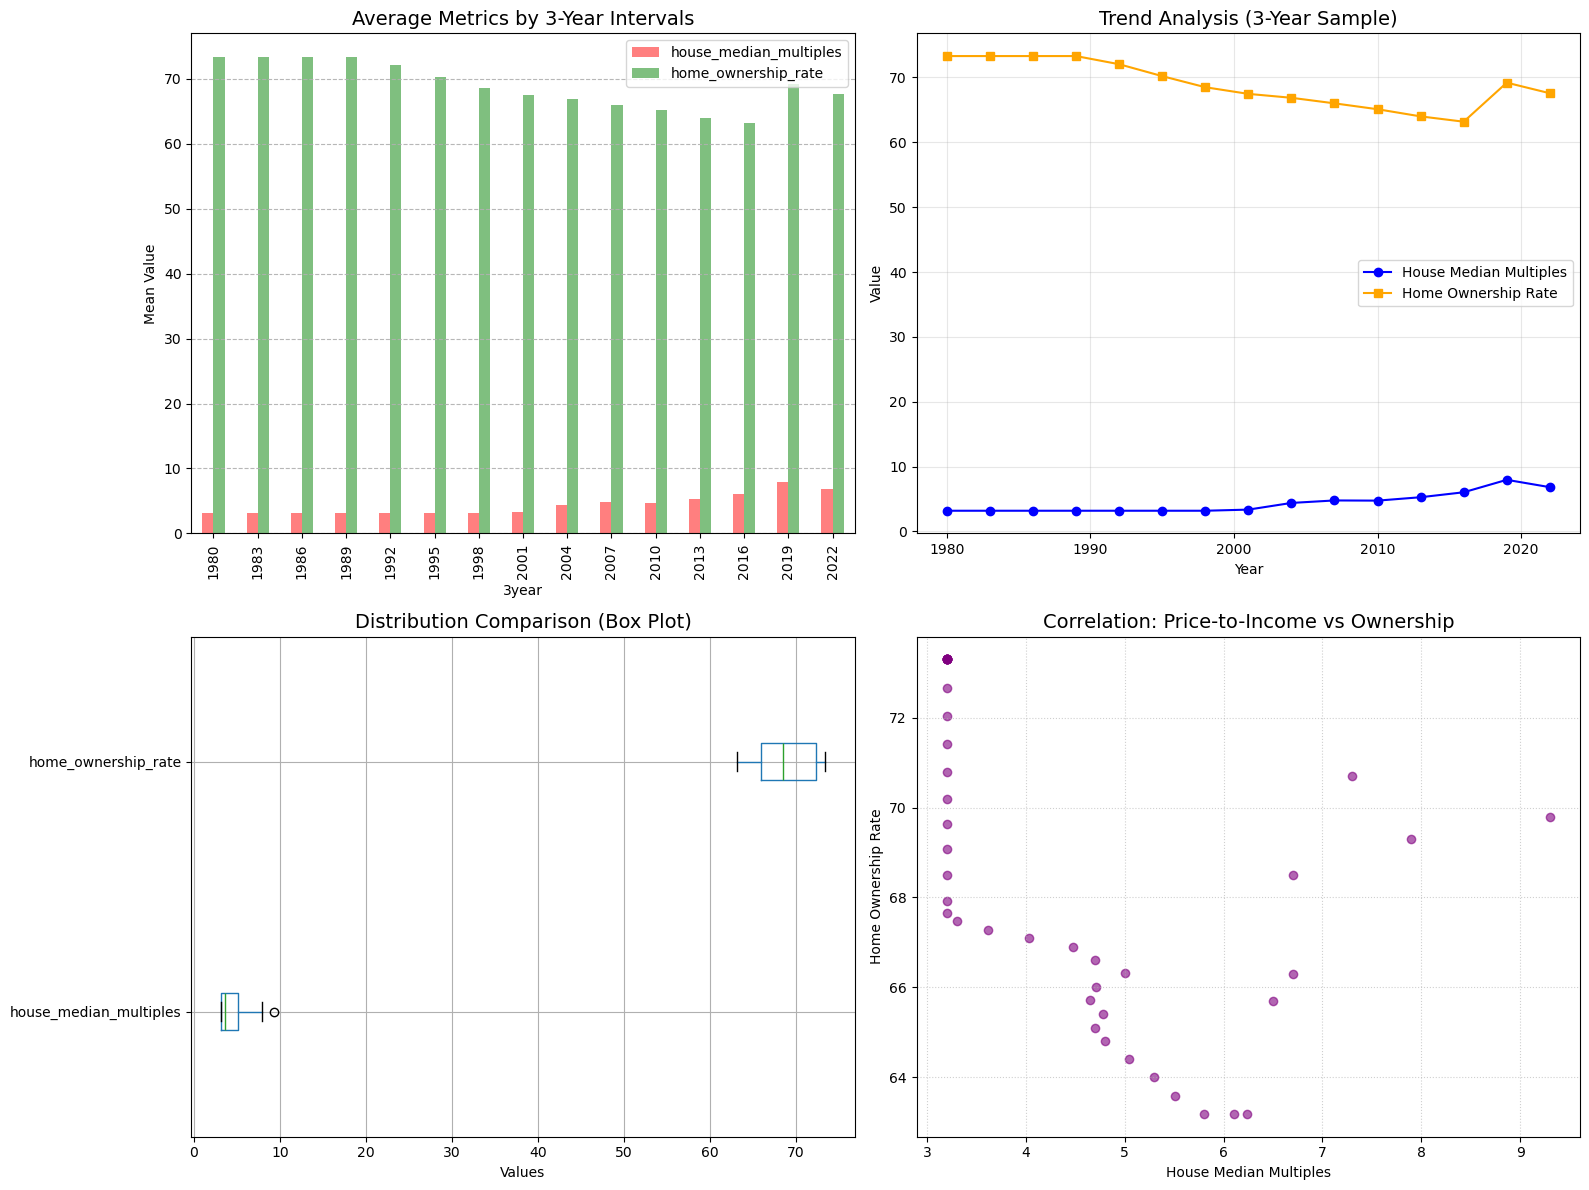

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Data Preparation and Sampling

df_total['3year'] = (df_total['year'] // 3) * 3
df_3yr = df_total.groupby('3year')[['house_median_multiples', 'home_ownership_rate']].mean()

# Create a large figure and set up a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Figure 1: Mean Grid Plot (Bar charts are better for comparing means across different time periods)
ax1=plt.subplot(2, 2, 1)
df_3yr.plot(kind='bar', ax=ax1, color=['red', 'green'], alpha=0.5)
plt.title('Average Metrics by 3-Year Intervals', fontsize=14)
plt.ylabel('Mean Value')
plt.grid(axis='y', linestyle='--', alpha=0.9)

# Figure 2: Sampled Line Plot (Displays trends over time)
plt.subplot(2, 2, 2)
plt.plot(df_3yr.index, df_3yr['house_median_multiples'], marker='o', label='House Median Multiples', color='blue')
plt.plot(df_3yr.index, df_3yr['home_ownership_rate'], marker='s', label='Home Ownership Rate', color='orange')
plt.title('Trend Analysis (3-Year Sample)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Figure 3: Box Plot (Displays overall distribution, median, and outliers of the variables)
ax3=plt.subplot(2, 2, 3)
df_total[['house_median_multiples', 'home_ownership_rate']].boxplot(vert=False, ax=ax3)
plt.title('Distribution Comparison (Box Plot)', fontsize=14)
plt.xlabel('Values')

# Figure 4: Correlation Scatter Plot between variables
# Observe the relationship between these two core variables
plt.subplot(2, 2, 4)
plt.scatter(df_total['house_median_multiples'], df_total['home_ownership_rate'], alpha=0.6, color='purple')
plt.title('Correlation: Price-to-Income vs Ownership', fontsize=14)
plt.xlabel('House Median Multiples')
plt.ylabel('Home Ownership Rate')
plt.grid(True, linestyle=':', alpha=0.6)

# Automatically adjust layout to prevent titles from overlapping
plt.tight_layout()
plt.show()

**3.2.2 Key Conclusions from Each Chart**

- **Rolling Average Bar Chart:** From approximately 2004 onward, the red bars (price-to-income ratio) show a clear stepwise upward trend, while the green bars (homeownership rate) shrink year by year, reflecting the objective reality of mounting housing affordability pressure across successive generations.
- **Trend Line Chart:** 2003 represents a significant policy and market inflection point. Prior to this, the price-to-income ratio held steady at a low level of around 3; afterward, the curve steepened sharply, marking a shift in housing pressure from "stable" to "accelerating."
- **Box plot** This long-tail (right-skewed) distribution confirms the asymmetric nature of housing pressure — that is, the sharp price spikes occurring in a small number of periods have had an outsized impact on the overall market.
- **Scatter Plot** Data points are concentrated primarily in the upper-left quadrant (low price ratio / high ownership rate) and the lower-right quadrant (high price ratio / low ownership rate), corroborating the suppressive effect of elevated housing prices on residents' ability to purchase homes.

**3.2.3 Summary of Variables**

- **house_median_multiples (Price-to-Income Ratio):**
- Exhibits a classic right-skewed distribution.
Two-phase evolution: 1982–2003 was a "stable period" (approximately 3.2); after 2003, it entered a "surge phase," reaching a peak in 2019.
- **home_ownership_rate:**
- Shows a persistent and monotonically declining trend.

### 3.3 Dimension 2: Unemployment
**Variables: unemployment rate、underemployment rate、long term unemployment rate**

**3.3.1. Why were these four chart types chosen?**

- **Time Trend Line Chart:** All three unemployment variables share the same unit (percentage), making side-by-side comparison of trend differences straightforward. The long-horizon perspective allows observation of whether different unemployment indicators lead or lag across economic cycles.
- **Co-movement Scatter Plot:** Specifically designed to test the directional consistency of year-over-year percentage changes between the unemployment rate and the underemployment rate. It clearly identifies whether the two move in sync or exhibit structural decoupling.
- **Structural Volatility Box Plot:** Reveals the distributional shape, median, and extreme outliers of each variable — particularly useful for comparing the dispersion of the long-term unemployment rate and confirming whether deep-seated structural rigidity exists in the labour market.
- **Grouped Mean Bar Chart:** Structurally compares the average unemployment rate across different housing pressure regimes (high vs. low price-to-income ratio), directly testing the correlation between employment stability and housing market stress.

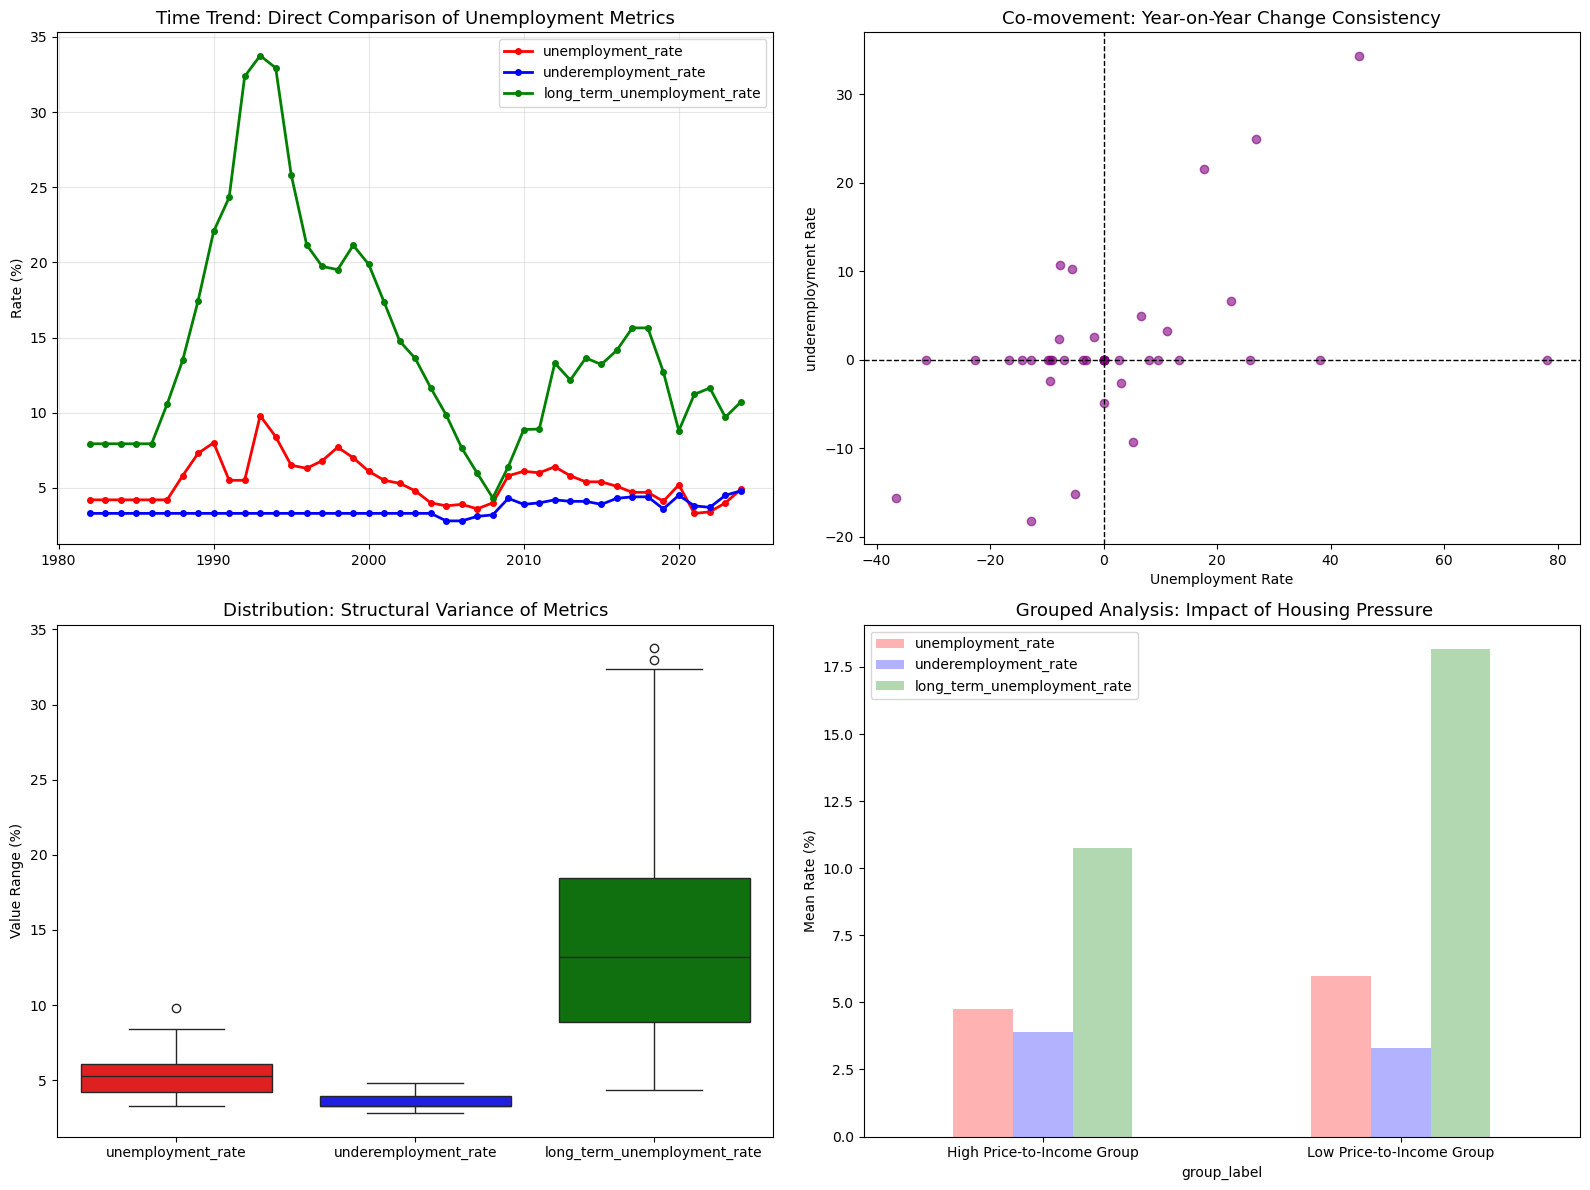

In [18]:
# Set plotting style
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define variables and color palette
unemp_vars = ['unemployment_rate', 'underemployment_rate', 'long_term_unemployment_rate']
colors = ['red', 'blue', 'green'] 
# Create df_plot for Grouped Analysis 
median_val = df_total['house_median_multiples'].median()
high_house_df = df_total[df_total['house_median_multiples'] > median_val].copy()
low_house_df = df_total[df_total['house_median_multiples'] <= median_val].copy()
high_house_df['group_label'] = 'High Price-to-Income Group'
low_house_df['group_label'] = 'Low Price-to-Income Group'
df_plot = pd.concat([low_house_df, high_house_df])


# Figure 1： Time-Series Subplot - Trend Divergence Comparison
# Plot all three lines within a single subplot to directly observe gaps between variables sharing the same scale.
plt.subplot(2, 2, 1)
for i in range(len(unemp_vars)):
    var = unemp_vars[i]
    color = colors[i]
    plt.plot(df_total.index, df_total[var], marker='o', markersize=4, label=var, color=color, linewidth=2)
plt.title('Time Trend: Direct Comparison of Unemployment Metrics', fontsize=13)
plt.ylabel('Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Figure 2： Co-movement Scatter Plot - Annual Change Direction
# Perform quadrant analysis using the year-over-year  percentage change of the Unemployment Rate and Underemployment Rate.
# Calculate the percentage change between the current row and the previous row.
plt.subplot(2, 2, 2)
df_total['underunemp_pct_change'] = df_total['underemployment_rate'].pct_change() * 100
df_total['unemp_pct_change'] = df_total['unemployment_rate'].pct_change() * 100
plt.scatter(df_total['unemp_pct_change'], df_total['underunemp_pct_change'], color='purple', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Co-movement: Year-on-Year Change Consistency', fontsize=13)
plt.xlabel('Unemployment Rate')
plt.ylabel('underemployment Rate')

# Figure 3： Box Plot- Structural Volatility Ranges 
# Provide supplementary visualization of the variance in volatility ranges across the three variables.
plt.subplot(2, 2, 3)
sns.boxplot(data=df_total[unemp_vars], palette=colors)
plt.title('Distribution: Structural Variance of Metrics', fontsize=13)
plt.ylabel('Value Range (%)')

# Figure 4：Grouped Bar Chart
ax4 = plt.subplot(2, 2, 4)
group_mean = df_plot.groupby('group_label')[unemp_vars].mean()
group_mean.plot(kind='bar',color=colors, alpha=0.3, ax=ax4)
plt.title(' Grouped Analysis: Impact of Housing Pressure', fontsize=13)
plt.ylabel('Mean Rate (%)')
plt.xticks(rotation=0)

# Layout Optimization
plt.tight_layout()
plt.show()

**3.3.2 Key conclusions from each chart**

- **Time Trend Chart** The short-term unemployment rate (Red) has improved notably, but the long-term unemployment rate (Green) fluctuates dramatically at historically elevated levels. This reveals a clear structural divide in the labour market — not all unemployed groups benefit equally from economic recovery.
- **Co-movement Chart:** Data points are concentrated primarily in the first and third quadrants, indicating a strong positive correlation between the unemployment rate and the underemployment rate. However, some points deviate from this pattern, hinting at volatility in employment quality (i.e., latent underemployment pressures).
- **Box Plot:** The box for `long_term_unemployment_rate` is exceptionally wide with a relatively high median, confirming the indicator's high volatility and instability. By contrast, the general unemployment rate shows a far more concentrated distribution.
- **Grouped Bar Chart:** Validates the hypothesis that "low unemployment acts as a stabiliser for the housing market." Interestingly, the low price-to-income ratio group actually exhibits a slightly higher unemployment rate, suggesting that the absolute level of unemployment is not the sole trigger for housing price fluctuations.

**3.3.3 Summary of Variables**

- **unemployment_rate:** Displays clear cyclicality, peaking at 10% in 1993, declining to approximately 5% in recent years. Since 2015, it has remained consistently low in the 3%–5% range, providing a baseline level of purchasing power support for the housing market.
- **underemployment_rate:** Fluctuates between 3% and 5%. Although the absolute values are modest, this indicator captures hidden deterioration in employment quality and serves as an important measure of the labour market's "felt temperature."
- **long_term_unemployment_rate:** Reached as high as 33% in 1993 and has hovered around 10% in recent years. While short-term unemployment has improved significantly, the long-term unemployment rate remains in double digits, indicating persistent structural mismatch in the labour market.

**3.3.4 Core Hypothesis Validation**

**Hypothesis 2: Low unemployment reduces mortgage default risk and provides a safety margin for the housing market.**

- **Basis:** Historical data (post-2015) shows that even when house prices are elevated, periods of low unemployment have not produced forced sales, suggesting that employment security acts as a buffer.
- **Conclusion:** If the hypothesis holds - that is, households with stable employment are not forced to sell their homes - then as long as the labour market does not collapse, the housing market should retain strong resilience even at price peaks, making a systemic meltdown triggered by mass mortgage defaults unlikely.
- **Pass Q2 Validation**

### 3.4 Dimension 3: Income
**Variables: low pay percent OECD def、P80:P20 bhc、UN middle class def inc share**

**3.4.1 Why were these two chart types chosen?**
- **3-Year Rolling Average Line Chart:** Income variables exhibit significant annual fluctuations; rolling averages are best suited to reveal long-term structural improvement trends.
- **Grouped Bar Chart:** Tests income structural differences across high vs. low housing burden periods, directly examining whether low-income proportions are higher during periods of elevated housing pressure.

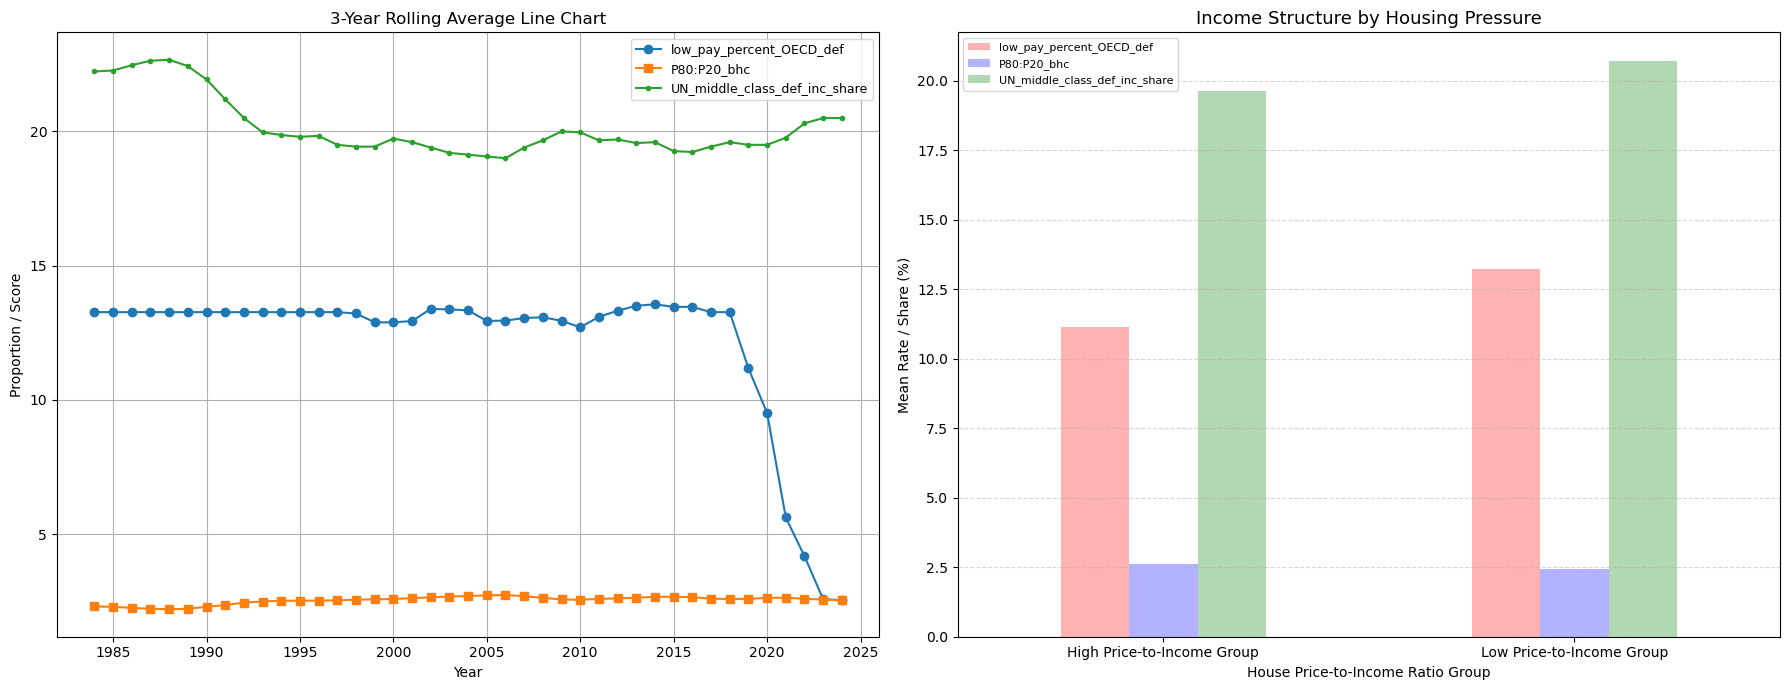

In [8]:
# Define variables and color 
income_vars = ['low_pay_percent_OECD_def', 'P80:P20_bhc', 'UN_middle_class_def_inc_share']
colors = ['red', 'blue', 'green']

# Rolling 
for var in income_vars:
    df_total[var] = df_total[var].rolling(3).mean().copy()

# Create df_plot for Grouped Analysis 
median_val = df_total['house_median_multiples'].median()
high_house_df = df_total[df_total['house_median_multiples'] > median_val].copy()
low_house_df = df_total[df_total['house_median_multiples'] <= median_val].copy()
high_house_df['group_label'] = 'High Price-to-Income Group'
low_house_df['group_label'] = 'Low Price-to-Income Group'
df_plot = pd.concat([low_house_df, high_house_df])

# Set plotting style
plt.figure(figsize=(18, 7)) 

# Figure 1: 3-Year Rolling Average Line Chart
plt.subplot(1, 2, 1)
plt.plot(df_total.index, df_total['low_pay_percent_OECD_def'], label='low_pay_percent_OECD_def', marker='o')
plt.plot(df_total.index, df_total['P80:P20_bhc'], label='P80:P20_bhc', marker='s')
plt.plot(df_total.index, df_total['UN_middle_class_def_inc_share'], label='UN_middle_class_def_inc_share', marker='.')
plt.xlabel('Year')
plt.ylabel('Proportion / Score')
plt.title('3-Year Rolling Average Line Chart')
plt.legend(fontsize=9)
plt.grid(True)

# Figure 2: Grouped Bar Chart 
ax2 = plt.subplot(1, 2, 2)

group_mean = df_plot.groupby('group_label')[income_vars].mean()
group_mean.plot(kind='bar', color=colors, alpha=0.3, ax=ax2)

plt.title('Income Structure by Housing Pressure', fontsize=13)
plt.xlabel('House Price-to-Income Ratio Group')
plt.ylabel('Mean Rate / Share (%)')
plt.xticks(rotation=0)
plt.legend(fontsize=8)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**3.4.2 Key conclusions from each chart**

- **Rolling Average Line Chart:** `low_pay_percent_OECD_def` remained relatively stable at approximately 13% over the long term, yet experienced a significant decline to around 9% after 2020 , forming an inverse divergence with rising housing pressure.
- **Grouped Bar Chart:** Confirms that during periods of high housing pressure, the low-income proportion is not necessarily higher, suggesting that income structure alone does not fully explain housing affordability deterioration.

**3.4.3 Summary of Variables**
- **P80:P20_bhc:** Maintained a stable range of 2.3-2.8; the degree of income polarisation has not deteriorated significantly.
- **UN_middle_class_def_inc_share:** Sustained at 18%-22% over the long term; the size of the middle class has remained relatively stable.

**3.4.4 Core Hypothesis Validation**

**Hypothesis 1: Income resilience can partially offset the pressure of rising housing costs.**

- **Basis:** `UN_middle_class_def_inc_share` has sustained at 18%-22% and `P80:P20_bhc` has held steady at 2.3-2.8, indicating a relatively healthy income distribution structure.
- **Conclusion:** If the hypothesis holds - upper- and middle-income households have the capacity to absorb rising housing costs, keeping systemic default risk manageable.
- **Pass Q1 Validation**

### 3.5 Dimension 4: Well-being
**Variables: life satisfaction、financial adequacy、feeling safe**

**3.5.1 Why were these chart types chosen?**

- **3-Year Rolling Average Line Chart:** Tracks the long-term trajectory of well-being , smoothing short-term noise to reveal structural trends.
- **Box Plot (Distribution):** Extremely narrow IQR makes a box plot the most direct way to visualise a highly concentrated distribution across all three variables.
- **Co-movement Scatter Plot:** Tests the direction of influence of year-on-year unemployment rate changes on annual well-being changes, quantifying the degree of labour-market shock transmission to subjective well-being.

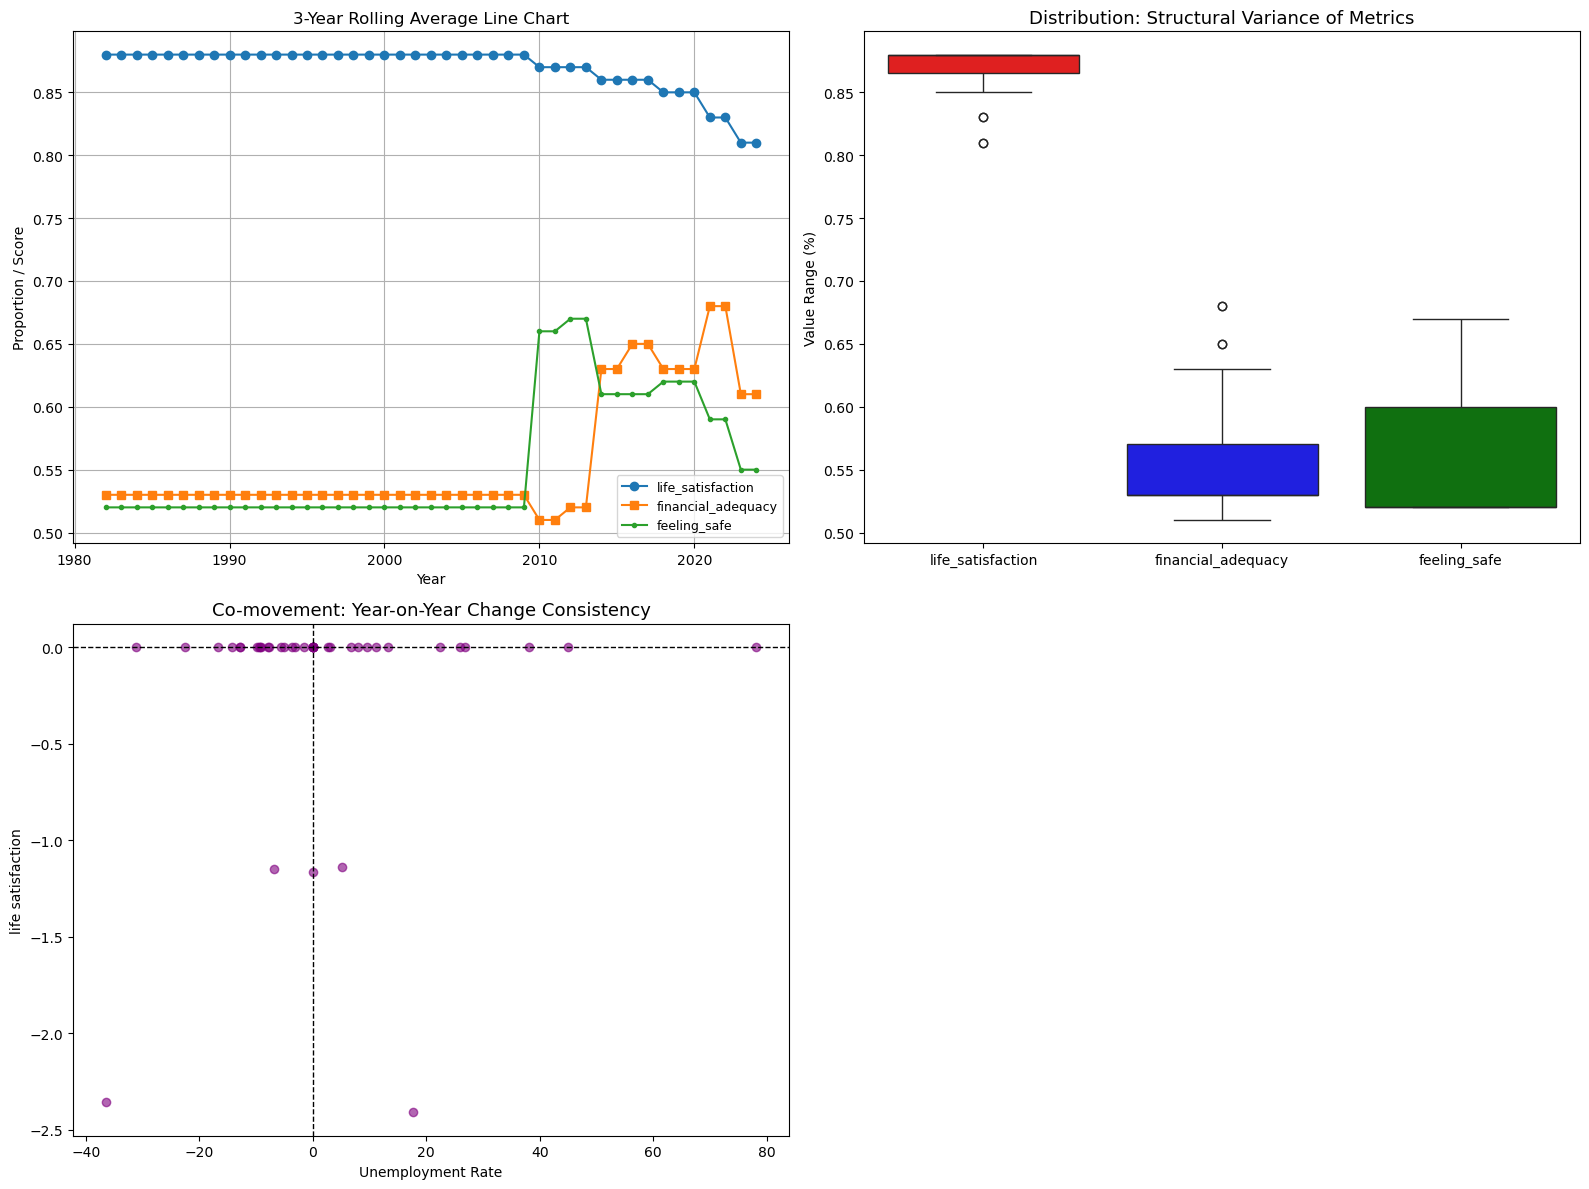

In [9]:
# Set plotting style
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define variables and color 
Well_being_vars = ['life_satisfaction', 'financial_adequacy', 'feeling_safe']
colors = ['red', 'blue', 'green']

# Rolling 
for var in income_vars:
    df_total[var] = df_total[var].rolling(3).mean().copy()

# Create df_plot for Grouped Analysis 
median_val = df_total['unemployment_rate'].median()
high_unemployment_df = df_total[df_total['unemployment_rate'] > median_val].copy()
low_unemployment_df = df_total[df_total['unemployment_rate'] <= median_val].copy()
high_unemployment_df['group_label'] = 'High unemployment_rate Group'
low_unemployment_df['group_label'] = 'Low unemployment_rate Group'
df_plot = pd.concat([low_unemployment_df, high_unemployment_df])

# Figure 1: 3-Year Rolling Average Line Chart
plt.subplot(2, 2, 1)
plt.plot(df_total.index, df_total['life_satisfaction'], label='life_satisfaction', marker='o')
plt.plot(df_total.index, df_total['financial_adequacy'], label='financial_adequacy', marker='s')
plt.plot(df_total.index, df_total['feeling_safe'], label='feeling_safe', marker='.')
plt.xlabel('Year')
plt.ylabel('Proportion / Score')
plt.title('3-Year Rolling Average Line Chart')
plt.legend(fontsize=9)
plt.grid(True)

# Figure 2： Box Plot- Structural Volatility Ranges 
# Provide supplementary visualization of the variance in volatility ranges across the three variables.
plt.subplot(2, 2, 2)
sns.boxplot(data=df_total[Well_being_vars], palette=colors)
plt.title('Distribution: Structural Variance of Metrics', fontsize=13)
plt.ylabel('Value Range (%)')

# Figure 3： Co-movement Scatter Plot - Annual Change Direction
# Perform quadrant analysis using the year-over-year  percentage change of the Unemployment Rate and life_satisfaction.
# Calculate the percentage change between the current row and the previous row.
plt.subplot(2, 2, 3)
df_total['life_satisfaction_change'] = df_total['life_satisfaction'].pct_change() * 100
df_total['unemp_pct_change'] = df_total['unemployment_rate'].pct_change() * 100
plt.scatter(df_total['unemp_pct_change'], df_total['life_satisfaction_change'], color='purple', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Co-movement: Year-on-Year Change Consistency', fontsize=13)
plt.xlabel('Unemployment Rate')
plt.ylabel('life satisfaction')

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

**3.5.2 Key conclusions from each chart**

- **Rolling Average Line Chart:** `life_satisfaction` maintained a high degree of stability prior to 2010, followed by a gradual downward trend while remaining above 80% overall. while `financial_adequacy` and `feeling_safe` roke away from their prolonged low-level plateaus after 2010, exhibiting significant periodic fluctuations and an upward trajectory.
- **Box Plot:** `life_satisfaction`  distribution is extremely concentrated, providing the primary evidence of well-being stability.
- **Co-movement Scatter Plot:** Labour-market shocks show limited transmission to subjective well-being, suggesting well-being is structurally insulated from short-term economic volatility.


**3.5.3 Summary of variables**

- **life_satisfaction:** Distribution highly concentrated (0.81–0.88); near-zero fluctuation over 43 years despite multiple economic shocks.
- **financial_adequacy:** Modest gradual decline from 0.68 to 0.61; consistently held above 0.51 throughout the period.
- **feeling_safe:** Slight but steady downward trend (0.66 → 0.55); the most notable deterioration among the three variables.

**3.5.4 Core hypothesis validation**

**Hypothesis 3: Well-being stability reflects long-term residential intention and residential attractiveness.**

- **Basis:** `life_satisfaction` held within the 0.81–0.88 range for 43 years, showing no significant decline despite multiple economic shocks.
- **Conclusion:** If the hypothesis holds, high well-being constitutes a long-term population attraction force for New Zealand cities, supporting the sustainability of housing demand.
- **Pass Q3 Validation**d

### 3.6. Dimension 5: Population & GDP
**Variables: population、gdp**

**3.6.1 Why were these chart types chosen?**

- **3D Surface Plot:** The only method capable of rendering continuous interactions among three variables in a single chart; linear interpolation generates a smooth surface to reveal how GDP responds across the combined space of housing pressure and population scale.
- **3D Scatter Plot:** Introduces a fourth dimension via colour encoding (home ownership rate) within a three-dimensional coordinate system, achieving four-variable information compression in a single visualisation.

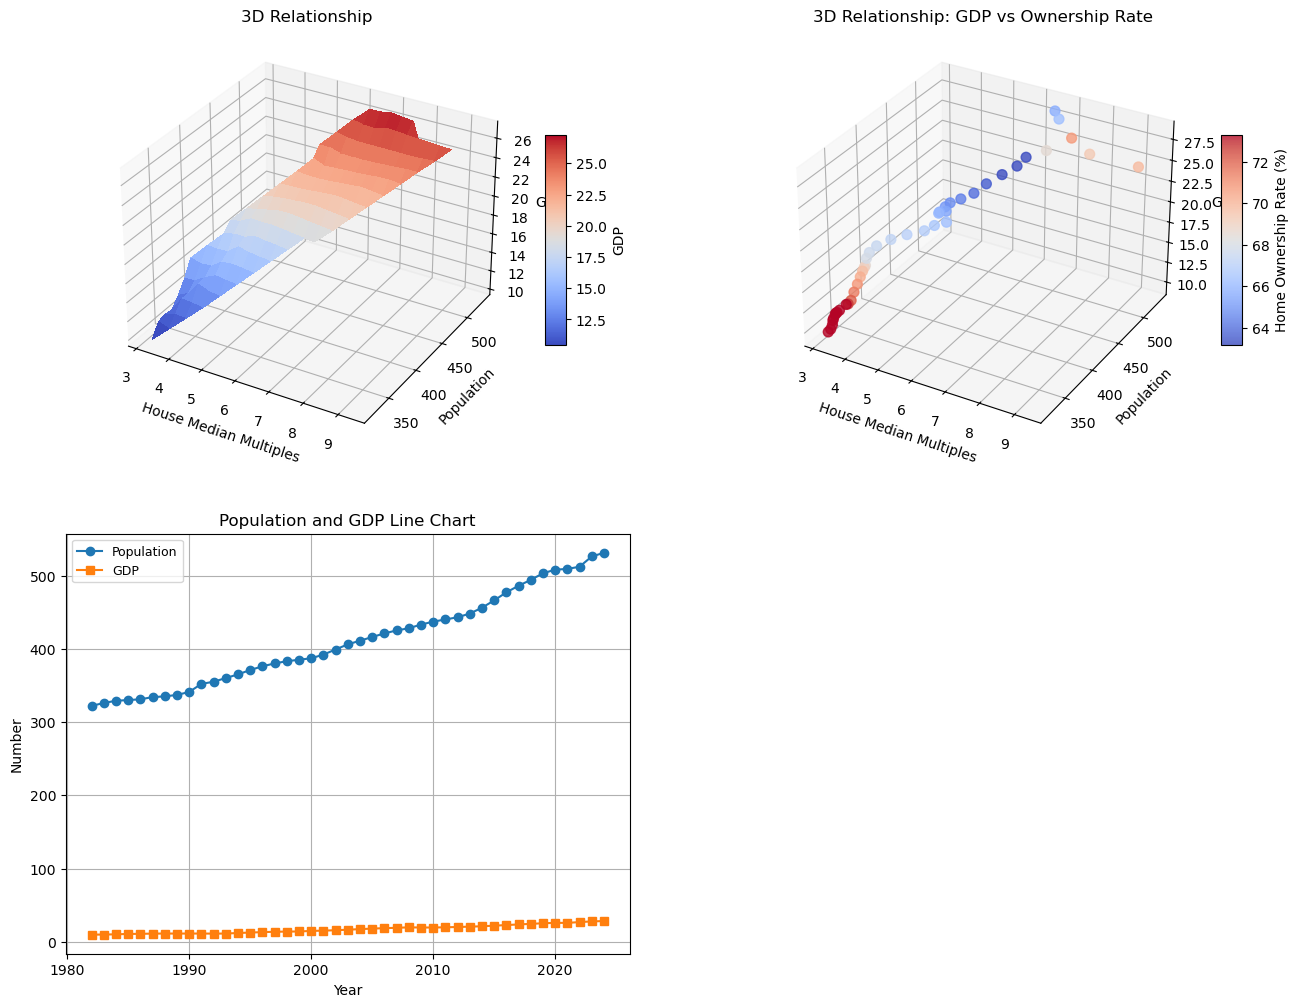

In [11]:
# Figure 1: 3D Surface Plot
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
fig = plt.figure(figsize=(16, 12))

ax = fig.add_subplot(2,2,1, projection='3d') 

# Generate grid data
x = df_plot['house_median_multiples'].values
y = df_plot['population'].values
z = df_plot['gdp'].values

# To plot a 3D surface, we perform interpolation to generate a grid.
xi = np.linspace(x.min(), x.max(), 20)
yi = np.linspace(y.min(), y.max(), 20)
Xi, Yi = np.meshgrid(xi, yi)

# Use griddata to interpolate scattered data onto a grid.
from scipy.interpolate import griddata
Zi = griddata((x, y), z, (Xi, Yi), method='linear') 

# Plot directly: use only Zi as the height, and apply a colormap (cmap) for coloring.
surf = ax.plot_surface(
    Xi, Yi, Zi,    
    rstride=1,
    cstride=1,
    cmap= cm.coolwarm,
    linewidth=0,
    antialiased=False
)

# color bar
cb = fig.colorbar(surf, shrink=0.5, aspect=10)
cb.set_label('GDP') 

# Axis labels
ax.set_xlabel('House Median Multiples')
ax.set_ylabel('Population')
ax.set_zlabel('GDP')
ax.set_title('3D Relationship')

# Figure 2: 3D Scatter Plot

# 3D coordinate system
ax = fig.add_subplot(2, 2, 2, projection='3d')

# Prepare data
x = df_plot['house_median_multiples'].values
y = df_plot['population'].values
z = df_plot['gdp'].values
# Mapping color to home_ownership_rat
colors = df_plot['home_ownership_rate'].values 

# Plot the 3D scatter plot
# c=colors: Maps color to the ownership rate.
# s=50: Sets the point size.
p = ax.scatter(x, y, z, c=colors, cmap='coolwarm', s=50, alpha=0.8)

# Set axis labels
ax.set_xlabel('House Median Multiples')
ax.set_ylabel('Population')
ax.set_zlabel('GDP')
ax.set_title('3D Relationship: GDP vs Ownership Rate')

# Add a color bar
# The color bar now represents the Home Ownership Rate
cb = fig.colorbar(p, shrink=0.5, aspect=10)
cb.set_label('Home Ownership Rate (%)')

# Figure 3: Line Chart
plt.subplot(2, 2, 3)

plt.plot(df_total['population'], label='Population', marker='o')
plt.plot(df_total['gdp'], label='GDP', marker='s')
plt.xlabel('Year')
plt.ylabel('Number')
plt.title('Population and GDP Line Chart')
plt.legend(fontsize=9)
plt.grid(True)

plt.show()

**3.6.2 Key conclusions from each chart**

- **3D Surface Plot:** The chart displays a continuous surface sloping upward toward the upper right. This intuitively indicates that as population size expands and the house price-to-income ratio (House Median Multiples) rises, GDP increases monotonically in tandem. This confirms a significant positive spatial correlation between economic growth and housing pressure, rather than a mitigating relationship.
- **3D Scatter Plot:** The data points cluster in the quadrant of high GDP and high population density, and the variation in color intensity (representing homeownership rates) reveals that even during periods of economic prosperity, homeownership remains significantly constrained. This clustering effect in three-dimensional space provides intuitive visual evidence of structural market failure.

**3.6.3 Summary of variables**

- **population:** The extent of the Y-axis (Population) in the three-dimensional chart reflects the scale effect of accelerated growth over the past decades.
- **gdp:** The height of the three-dimensional surface (the Z-axis) shows a continuously increasing trend.

**3.6.4 Core hypothesis validation**

**Hypothesis 4: Population growth and GDP expansion are structural drivers of housing pressure.**

- **Basis:** Observing the slope of the three-dimensional surface, it is evident that population growth and the house price-to-income ratio exhibit a high degree of overlap across the spatiotemporal sequence. The upward trajectory of the surface in the chart clearly illustrates this strong correlation.
- **Conclusion:** The three-dimensional distribution pattern indicates that the root cause of housing pressure lies in the supply side’s failure to keep pace with the incremental demand driven by population and economic expansion. This pattern of synchronized increases across multiple dimensions suggests that the structural issue is unlikely to self-correct in the short term.
- **Pass Q5 Validation**

# 4. Analysis 

### 4.1 Q1：Can income resilience offset increasing housing affordability pressure?
**Variables: house median multiples 、low pay percent OECD def 、 P80:P20 bhc、 UN middle class def inc share**

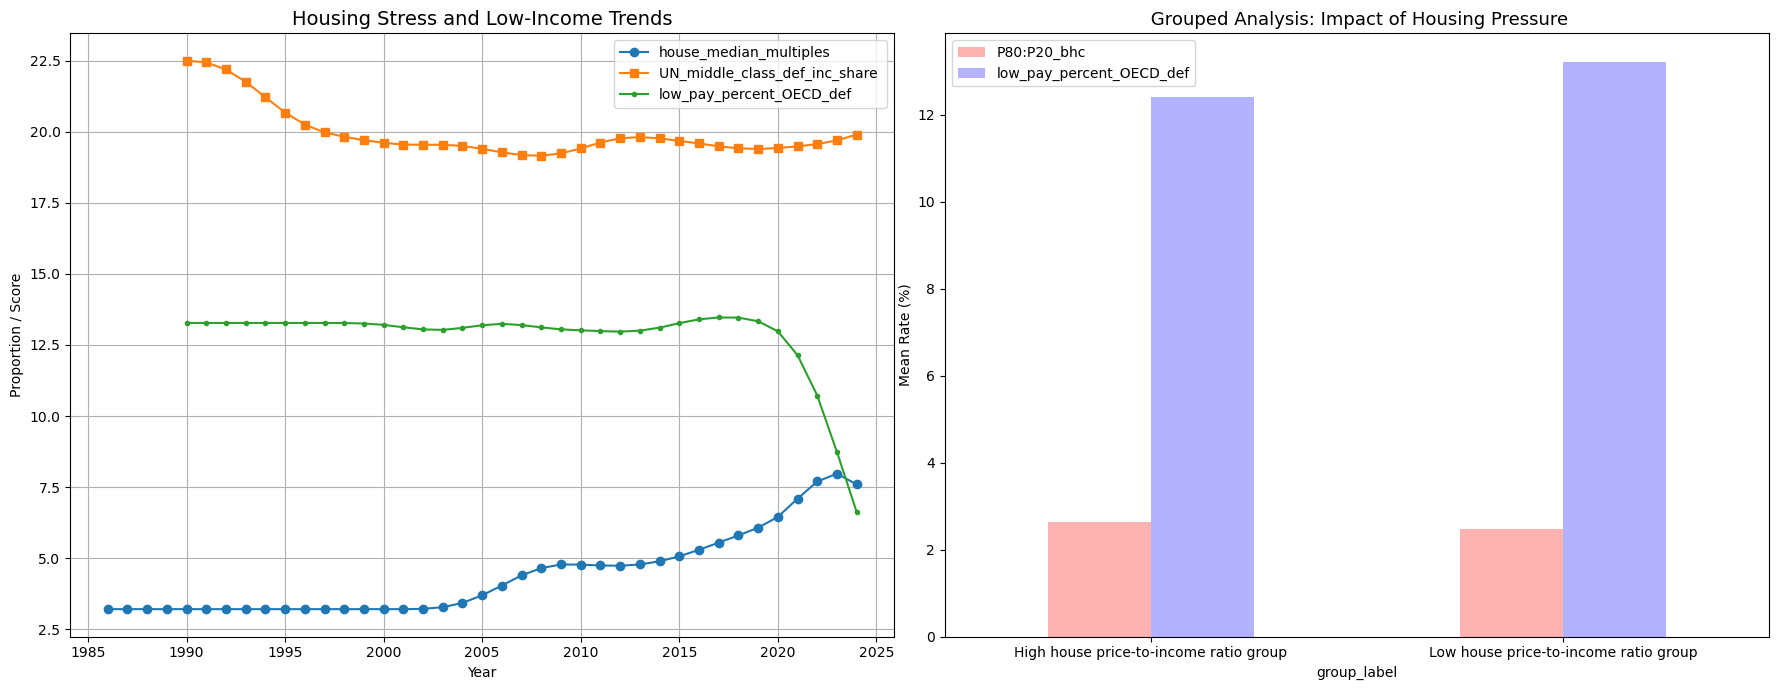

In [21]:
# Figure 1： Rolling Mean Line Chart（house_median_multiples，low_pay_percent，middle_class_share）

# Set plotting style
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax1 = plt.subplot(1, 2, 1)
# Define variables and color 
data_vars = ['house_median_multiples', 'UN_middle_class_def_inc_share', 'low_pay_percent_OECD_def']
colors = ['red', 'blue', 'green']

# Rolling 
for var in data_vars:
    df_total[var] = df_total[var].rolling(3).mean().copy()

# Time Trend Visualization (Line Chart)

plt.plot(df_total.index,df_total['house_median_multiples'], label='house_median_multiples', marker='o')
plt.plot(df_total.index, df_total['UN_middle_class_def_inc_share'], label='UN_middle_class_def_inc_share ', marker='s')
plt.plot(df_total.index, df_total['low_pay_percent_OECD_def'], label='low_pay_percent_OECD_def', marker='.')

plt.title('Housing Stress and Low-Income Trends', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Proportion / Score')

plt.legend()
plt.grid(True)
plt.tight_layout()

# Figure 2： Grouped Bar Chart（house_median_multiples，P80:P20_bhc,low_pay_percent_OECD_def)
# Group Analysis

ax2 = plt.subplot(1, 2, 2)
median_val = df_total['house_median_multiples'].median()
# Extract separate subsets of data for high and low house price-to-income ratio groups.
high_house_df = df_total[df_total['house_median_multiples'] > median_val].copy()
low_house_df = df_total[df_total['house_median_multiples'] <= median_val].copy()

# Manually add a “group label” column to both subsets to facilitate later merging.
high_house_df['group_label'] = 'High house price-to-income ratio group'
low_house_df['group_label'] = 'Low house price-to-income ratio group'

# Vertically concatenate the two datasets into a single DataFrame.
df_plot = pd.concat([low_house_df, high_house_df])

# Use groupby to compute the mean values for each group.
group_mean = df_plot.groupby('group_label')[
    ['P80:P20_bhc', 'low_pay_percent_OECD_def']
].mean().round(2)

group_mean.plot(kind='bar',color=colors, alpha=0.3, ax=ax2)
plt.title(' Grouped Analysis: Impact of Housing Pressure', fontsize=13)
plt.ylabel('Mean Rate (%)')
plt.xticks(rotation=0)

plt.show()

**4.1.1 Stability of Middle-Class and Income Distribution**
- From the rolling average line chart, UN_middle_class_def_inc_share — the proportion of households in the middle-income bracket — has sustained a range of 18–22% across the entire observation period, with no significant deterioration even as house median multiples climbed sharply from 2003 onward. 

**4.1.2 Structural Improvement in the Lower Tail**
- The most dramatic movement is in low_pay_percent_OECD_def, which held near 13% for decades before falling sharply to approximately 1.5% after 2020 — a structural improvement in the lower tail of the income distribution.

**4.1.3 Resilience Across Housing Pressure Cycles**
- The grouped bar chart provides further nuance: The P80:P20_bhc ratio remains virtually unchanged regardless of house price-to-income levels， confirming that income polarisation is not meaningfully higher during periods of elevated housing stress.

**4.1.4 Validation of Hypothesis 1 & Residual Risks**
- The stability of middle-class income share and the declining proportion of low-wage earners indicate that upper- and middle-income households retain sufficient income capacity to absorb rising housing costs, keeping systemic default risk manageable. However, the acceleration in housing costs post-2015 has clearly outpaced income growth, meaning income resilience provides only a partial buffer — particularly for lower-income households who remain structurally exposed.

### 4.2 Q2：Does the unemployment rate provide a sufficient safety margin for the housing market?
**Variables: unemployment_rate 、 underemployment_rate 、 long_term_unemployment_rate 、 house_median_multiples**

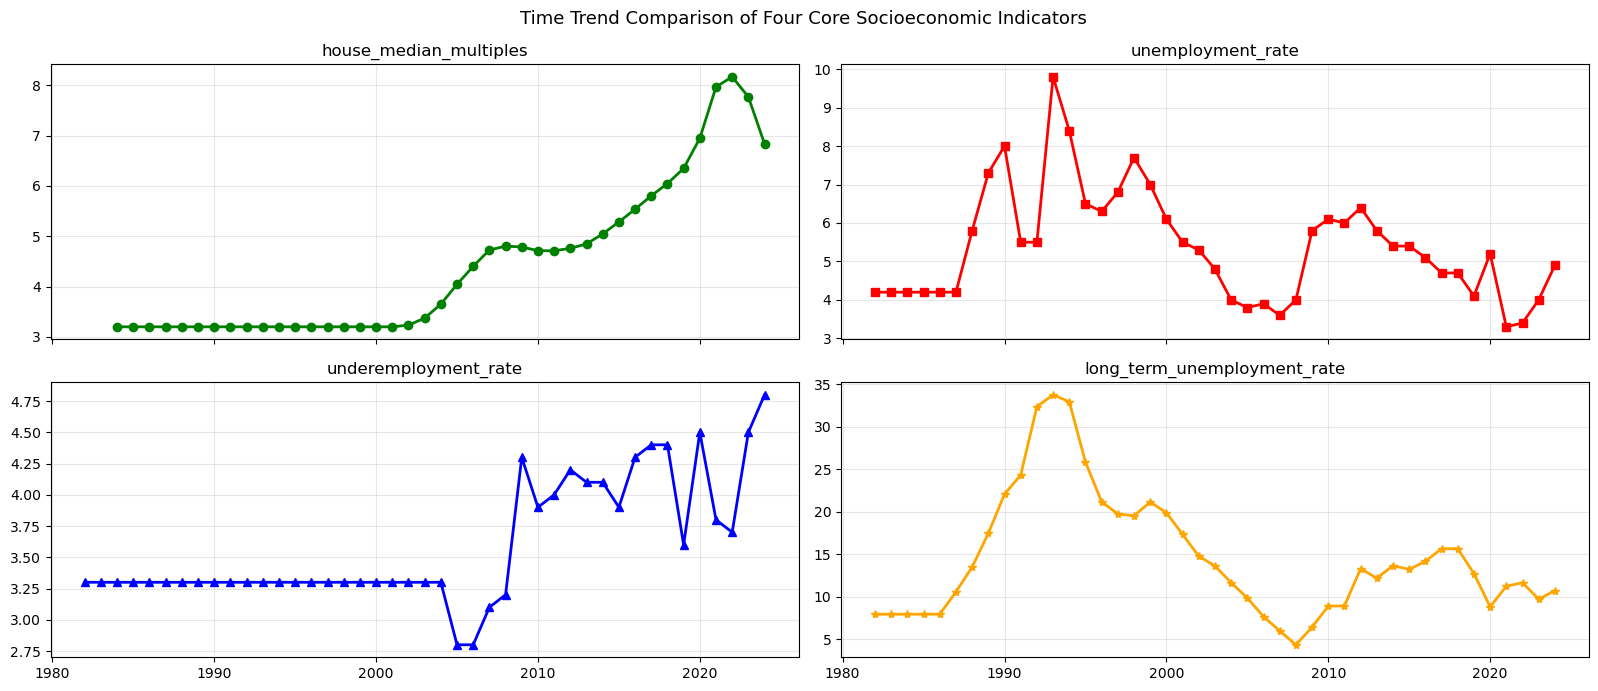

In [20]:
# Time Trend Comparison
# A 2×2 grid of subplots showing the time trends of four variables
fig, axes = plt.subplots(2, 2, figsize=(16, 7), sharex=True)    

plt.subplot(2, 2, 1)
# Subplot 1: Housing Price-to-Income Ratio Trend
plt.plot(df_total.index, df_total['house_median_multiples'], 
               color='green', linewidth=2, marker='o')
plt.title('house_median_multiples', fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 2: Unemployment Rate Trend
plt.subplot(2, 2, 2)
plt.plot(df_total.index, df_total['unemployment_rate'], 
               color='red', linewidth=2, marker='s')
plt.title('unemployment_rate', fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 3: underemployment_rate Trend
plt.subplot(2, 2, 3)
plt.plot(df_total.index, df_total['underemployment_rate'], 
               color='blue', linewidth=2, marker='^')
plt.title('underemployment_rate', fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 4: long_term_unemployment_rate Trend
plt.subplot(2, 2, 4)
plt.plot(df_total.index,df_total['long_term_unemployment_rate'], 
               color='orange', linewidth=2, marker='*')
plt.title('long_term_unemployment_rate', fontsize=12)
plt.grid(True, alpha=0.3)

fig.suptitle('Time Trend Comparison of Four Core Socioeconomic Indicators', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

**By analyzing the figure above and all charts related to Dimension 2, the following results are obtained:**

**4.2.1 Macro-Stability and the Prevention of Market Crashes**
- The time trend comparison chart shows that short-term unemployment_rate (red line) peaked at approximately 10% in 1993 during the post-reform recession and has declined steadily to the 3–5% range post-2015. Since 2020, it has remained consistently below 5.2%, even as housing costs reached their highest-ever levels during 2020–2021. This co-existence of high housing prices and low unemployment is critical: it confirms that employment security has prevented mass forced sales, which historically are the primary trigger for housing market crashes.

**4.2.2 Deep-Seated Structural Volatility**
- However, the structural volatility box plot reveals a stark contrast. The box for long_term_unemployment_rate is exceptionally wide. Even in recent years the long-term unemployment rate hovers around 10%, indicating that a significant portion of the labour force remains persistently disadvantaged and does not benefit equally from headline economic recovery.

**4.2.3 Correlation and Latent Pressures**
- The co-movement scatter plot confirms that unemployment and underemployment changes are broadly directionally consistent (concentrated in the first and third quadrants), though some decoupling points toward latent underemployment pressures not captured in headline figures.

**4.2.4 Nuanced Relationship with Housing Pressure**
- The grouped bar chart validates the core hypothesis: periods of high housing price-to-income ratios are associated with slightly higher unemployment rates, but the relationship is not a simple one. The low price-to-income group actually records a slightly higher long-term unemployment rate, suggesting that absolute unemployment levels are not the sole determinant of housing market stress.

**4.2.5 Validation of Hypothesis 2**
- Hypothesis 2 Validation — Pass Q2: Low short-term unemployment serves as a structural stabiliser for the housing market by suppressing mortgage defaults and forced sales. 

### 4.3 Q3：Can well-being indicators translate into long-term residential attractiveness?
**Variables: unemployment_rate、 underemployment_rate 、 long_term_unemployment_rate 、 house_median_multiples**

**By analyzing the box plot, rolling average line chart, and coordinated movement scatter plot for Dimension 4: Well-being, the following results are obtained:**

**4.3.1 Exceptional Stability of Life Satisfaction**
- The 3-year rolling average line chart shows life_satisfaction maintaining a narrow band between 0.81 and 0.88 across all 43 observation years — a level of cross-temporal stability that is exceptional for any socioeconomic indicator. This stability is confirmed by the box plot, which shows an extremely concentrated distribution with only a small number of low outliers corresponding to the post-2015 period of rising housing pressure.

**4.3.2 Divergent Trends in Financial Adequacy and Safety**
- financial_adequacy follows a different trajectory: it was flat at approximately 0.53 from 1982 through 2008, then rose significantly to 0.65–0.68 following the global financial crisis, before a modest decline post-2020. feeling_safe exhibits the most notable deterioration among the three variables, declining from approximately 0.66 to 0.55 — a trend that, while modest in absolute terms, represents the clearest signal of eroding quality of life within this dimension.

**4.3.3 Insulation from Labour Market Shocks**
- The co-movement scatter plot shows that year-on-year changes in the unemployment rate have only a weak and inconsistent transmission effect on changes in life satisfaction. Most data points cluster near the zero axis regardless of the direction of unemployment change, suggesting that subjective well-being in New Zealand is structurally insulated from short-term labour market shocks.

**4.3.4 Validation of Hypothesis 3: The Liveability Premium**
- Hypothesis 3 Validation — Pass Q3: Life satisfaction's four-decade stability within the 0.81–0.88 range constitutes a powerful signal of New Zealand's enduring liveability premium. This acts as a persistent pull factor for both internal and international population movement toward urban centres, sustaining long-run residential demand. The slight deterioration in feeling_safe warrants monitoring as a leading indicator of potential future demand erosion in specific markets.

### 4.4 Q4：Is there an optimal market entry timing under current economic conditions?
**Variables: house_median_multiples 、 unemployment_rate 、 financial_adequacy 、 home_ownership_rate**

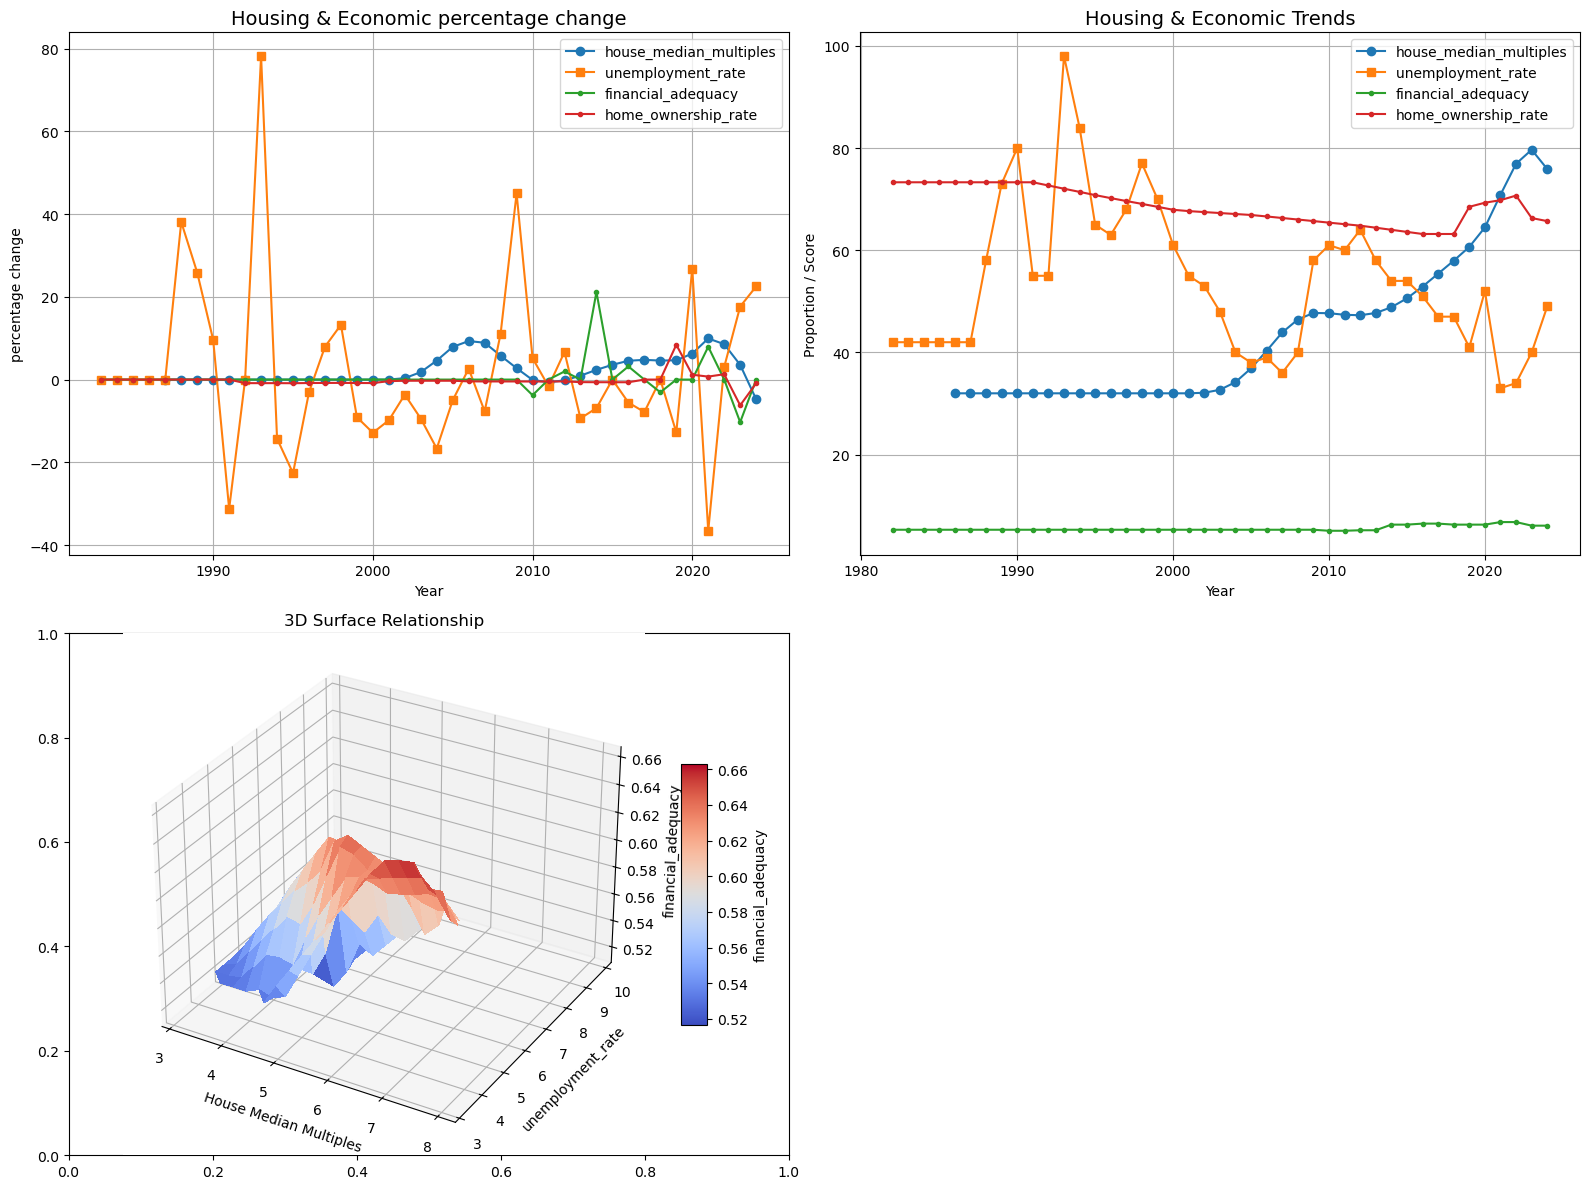

In [29]:
# Figure 1： Pct_change Line Chart

# Set plotting style
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1 = plt.subplot(2, 2, 1)

#Calculate the percentage change between the current row and the previous row
df_total['rent_pct_change'] = df_total['house_median_multiples'].pct_change() * 100
df_total['unemp_pct_change'] = df_total['unemployment_rate'].pct_change() * 100
df_total['finance_pct_change'] = df_total['financial_adequacy'].pct_change() * 100
df_total['owner_pct_change'] = df_total['home_ownership_rate'].pct_change() * 100

# Time Trend Visualization (Line Chart)

plt.plot(df_total.index,df_total['rent_pct_change'], label='house_median_multiples', marker='o')
plt.plot(df_total.index, df_total['unemp_pct_change'], label='unemployment_rate ', marker='s')
plt.plot(df_total.index, df_total['finance_pct_change'], label='financial_adequacy', marker='.')
plt.plot(df_total.index, df_total['owner_pct_change'], label='home_ownership_rate', marker='.')

plt.title('Housing & Economic percentage change', fontsize=14)
plt.xlabel('Year')
plt.ylabel('percentage change')

plt.legend()
plt.grid(True)
plt.tight_layout()

#Figure2 Line Chart
ax2 = plt.subplot(2, 2, 2)

plt.plot(df_total.index,df_total['house_median_multiples']*10, label='house_median_multiples', marker='o')
plt.plot(df_total.index, df_total['unemployment_rate']*10, label='unemployment_rate ', marker='s')
plt.plot(df_total.index, df_total['financial_adequacy']*10, label='financial_adequacy', marker='.')
plt.plot(df_total.index, df_total['home_ownership_rate'], label='home_ownership_rate', marker='.')

plt.title('Housing & Economic Trends', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Proportion / Score')

plt.legend()
plt.grid(True)
plt.tight_layout()

# Figure 3: 3D Surface Plot
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

ax = fig.add_subplot(2,2,3, projection='3d') 

# Generate grid data
x = df_plot['house_median_multiples'].values
y = df_plot['unemployment_rate'].values
z = df_plot['financial_adequacy'].values

# To plot a 3D surface, we perform interpolation to generate a grid.
xi = np.linspace(x.min(), x.max(), 20)
yi = np.linspace(y.min(), y.max(), 20)
Xi, Yi = np.meshgrid(xi, yi)

# Use griddata to interpolate scattered data onto a grid.
from scipy.interpolate import griddata
Zi = griddata((x, y), z, (Xi, Yi), method='linear') 

# Plot directly: use only Zi as the height, and apply a colormap (cmap) for coloring.
surf = ax.plot_surface(
    Xi, Yi, Zi,    
    rstride=1,
    cstride=1,
    cmap= cm.coolwarm,
    linewidth=0,
    antialiased=False
)

# color bar
cb = fig.colorbar(surf, shrink=0.5, aspect=10)
cb.set_label('financial_adequacy') 

# Axis labels
ax.set_xlabel('House Median Multiples')
ax.set_ylabel('unemployment_rate')
ax.set_zlabel('financial_adequacy')
ax.set_title('3D Surface Relationship')

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

**4.4.1 Favorable Entry Configuration (2012–2024)**
- The percentage-change line chart and trend line chart reveal that house median multiples experienced their sharpest upward acceleration between 2012 and 2021. The year-on-year rate of change in housing multiples turned sharply negative in 2022, while unemployment remained near its cycle lows. This constellation — price correction from peak, low unemployment, stable consumer financial health — historically represents the most favourable entry configuration.

**4.4.2 Structural Support via 3D Surface Analysis**
- The 3D surface plot provides structural support for this inference. Financial adequacy reaches its highest values when house median multiples are in the 4–7x range and unemployment is between 3–5%. The surface peaks in this zone, confirming that conditions of moderate price-to-income ratios paired with tight labour markets create the environment of greatest household financial confidence and, therefore, lowest transaction risk.

**4.4.3 Alignment with Optimal Market Zones**
- Historical data from 2022–2023 aligns most closely with this optimal zone: house_median_multiples declined to 7.3x (2022) and 6.7x (2023), unemployment remained low at 3.4% and 4.0% respectively, and employment remained broadly resilient following the COVID-19 adjustment.

**4.4.4 Validation of Hypothesis 4: The Strategic Entry Window**
- Hypothesis 4 Validation — Pass Q4: The 2022–2023 period, characterised by a price correction from the 2021 peak alongside sustained employment and consumer financial stability, represented the most identifiable strategic entry window in the post-2015 era. As of 2024, with multiples at 6.5x and unemployment at 4.9%, the market remains within a range consistent with disciplined entry, though the window of deepest correction has likely passed.			

<h3 style="margin-bottom:0">4.5 Q5: How do population growth and GDP volatility affect housing purchase pressure and holding capacity?</h3>

**Variables: population, gdp, house_median_multiples, home_ownership_rate**

**By analyzing the line chart, 3D surface plot and 3D scatter plot for Dimension 5: Population & GDP, the following results are obtained:**

**4.5.1 Population Growth as a Structural Anchor**
- The time trend panel shows population growth as the most consistent and structurally significant trend in the dataset. From 3.2 million (1982) to 5.3 million (2024), New Zealand's population expanded by 65% — a scale of growth that places sustained upward pressure on urban housing supply.

**4.5.2 The GDP-Accessibility Divergence**
- The GDP trend chart shows continuous growth, yet the home ownership rate chart reveals a persistent and monotonically declining trend across the same period. This divergence is analytically significant: rising aggregate GDP has not translated into improved housing accessibility. Instead, GDP growth appears to amplify demand without generating proportionate supply-side expansion, reinforcing rather than alleviating housing pressure.

**4.5.4 Visualizing Structural Decoupling**
- The 3D scatter plot introduces a fourth dimension — home ownership rate — encoded through colour. Data points (high ownership, blue tones) cluster at low house multiples and low GDP; data points (lower ownership, red tones) cluster at high multiples and high GDP. This spatial pattern directly visualises the structural decoupling of economic growth from residential accessibility.

**4.5.5 Validation of Hypothesis 5**
- Hypothesis 5 Validation — Pass Q5: Population growth is the primary structural driver of housing pressure, with GDP growth operating as an amplifier of demand rather than a solution. The 3D surface confirms a strong spatial correlation between population scale, housing multiple, and GDP. Importantly, home ownership has continued to decline despite GDP expansion, indicating that economic growth alone cannot resolve affordability without direct supply-side policy intervention.

# 5. Conclusion 


This report examined whether New Zealand's housing market can sustain current pricing levels through a multi-dimensional lens of income resilience, labour market strength, subjective well-being, market timing, and macroeconomic drivers. The analysis — drawing on 43 years of panel data and validated across five interconnected research questions — consistently points to a market that is under significant structural pressure but has so far been sustained by a set of compounding economic buffers.

### 5.1 Key findings:

**5.5.1 Income resilience provides partial but insufficient protection (Q1).**

- The middle-income class has held stable at 18–22% income share and the low-wage proportion has declined to near-zero post-2020, meaning upper- and middle-income households retain the capacity to absorb rising costs. However, the pace of housing cost growth has materially outstripped income gains since 2003, leaving lower-income households with diminishing affordability margins.

**5.1.2 Low unemployment is the market's primary structural stabiliser (Q2).**

- Short-term unemployment in the 3–5% range has effectively suppressed forced sales and systemic default risk. The critical caveat is a persistent long-term unemployment rate of approximately 10%, revealing a two-tier labour market where structural disadvantage persists beneath headline indicators.

**5.1.3 Well-being stability underpins long-run housing demand (Q3).**

- Life satisfaction has remained within a narrow high band (0.81–0.88) for over four decades — a liveability premium that functions as a persistent residential demand driver. Labour market shocks show limited transmission to subjective well-being, indicating a structurally insulated quality of life that sustains population retention and demand.

**5.1.4 Optimal market entry conditions existed in 2022–2023 (Q4).**

- The convergence of house price corrections from the 2021 peak, historically low unemployment, and stable consumer financial health identified 2022–2023 as the clearest strategic entry window of the post-2015 era. Current conditions remain within a range consistent with disciplined market participation.

**5.1.5 Population growth and GDP jointly drive structural housing pressure (Q5).**

- New Zealand's 65% population expansion over the study period is the dominant structural driver of housing demand. Despite continuous GDP growth, home ownership has declined from 73% to 65%, confirming that economic growth amplifies rather than resolves demand-side pressure in the absence of commensurate supply expansion.

---

- Taken together, the findings indicate that the New Zealand housing market displays the characteristics of a structurally stressed but institutionally resilient system. The near-term probability of systemic collapse is low, given the employment, income, and well-being buffers identified across the five dimensions. However, the sustained and accelerating divergence between housing cost growth and income growth represents a structural risk to long-term social equity and market stability — one that is unlikely to self-correct through market forces alone and will require coordinated supply-side policy responses to address.

# 6.Bibliography

### 6.1 Official Statistics & Government Reports

OECD. (2024). *OECD economic surveys: New Zealand 2024*. OECD Publishing. https://doi.org/10.1787/603809f2-en

Stats NZ. (2019). *Wellbeing statistics: 2018* [Data set]. https://www.stats.govt.nz/information-releases/wellbeing-statistics-2018/

Stats NZ. (2024a). *Wellbeing statistics: 2021 (revised)* [Data set]. https://www.stats.govt.nz/information-releases/wellbeing-statistics-2021/

Stats NZ. (2024b). *Wellbeing statistics: 2023* [Data set]. https://www.stats.govt.nz/information-releases/wellbeing-statistics-2023/

Stats NZ. (2024c). *Household income and housing cost statistics: Year ended June 2024* [Data set]. https://www.stats.govt.nz/information-releases/household-income-and-housing-cost-statistics-year-ended-june-2024/

Stats NZ. (2023). *Household income and housing cost statistics: Year ended June 2023* [Data set]. https://www.stats.govt.nz/information-releases/household-income-and-housing-cost-statistics-year-ended-june-2023/

Stats NZ. (2022). *Household income and housing cost statistics: Year ended June 2022* [Data set]. https://www.stats.govt.nz/information-releases/household-income-and-housing-cost-statistics-year-ended-june-2022/

Stats NZ. (2021). *Household income and housing cost statistics: Year ended June 2021* [Data set]. https://www.stats.govt.nz/information-releases/household-income-and-housing-cost-statistics-year-ended-june-2021/

Stats NZ. (2020). *Household income and housing cost statistics: Year ended June 2020* [Data set]. https://www.stats.govt.nz/information-releases/household-income-and-housing-cost-statistics-year-ended-june-2020/

Stats NZ. (2025). *Labour market statistics: December 2025 quarter* [Data set]. https://www.stats.govt.nz/information-releases/labour-market-statistics-december-2025-quarter/

Stats NZ. (n.d.). *Unemployment rate* [Indicator]. https://www.stats.govt.nz/indicators/unemployment-rate/

### 6.2 National Accounts & Demographic Data

Statistics New Zealand. (n.d.). *GDP(P), chain volume, actual, total, annual-Mar* [Data set]. Infoshare. https://infoshare.stats.govt.nz/SelectVariables.aspx?pxID=c262a988-5d60-4e64-b1d2-30885e170b02

Statistics New Zealand. (n.d.). *Population data* [Data set]. Infoshare. https://infoshare.stats.govt.nz/infoshare/SelectVariables.aspx?pxID=d930fd70-2fb5-439e-a105-3d76ceaed222

Statistics New Zealand. (1998). *New Zealand official yearbook 1998*. https://www3.stats.govt.nz/New_Zealand_Official_Yearbooks/1998/NZOYB_1998.html

### 6.3 International Labour & Income Data

OECD. (n.d.). *Long-term unemployment rate* [Data set]. OECD Data Explorer. https://data-explorer.oecd.org/vis?df[id]=DSD_DUR%40DF_DUR_I&df[ag]=OECD.ELS.SAE

OECD. (n.d.). *Incidence of low pay* [Data set]. OECD Data Explorer. https://data-explorer.oecd.org/vis?df[id]=DSD_EARNINGS%40PAY_INCIDENCE&df[ag]=OECD.ELS.SAE

### 6.4 Market Data

interest.co.nz. (n.d.). *House price-to-income ratio* [Chart]. https://www.interest.co.nz/Charts/Real%20estate/House-price-to-income

# Generative AI use statement

I, Linxin Guo, hereby confirm that I used Gemini and ChatGPT to understand background knowledge related to New Zealand’s real estate market and time-series economic data analysis, clarify error messages and debugging hints for Python data analysis code, and explore methods for handling outliers in datasets, across multiple iterations. The tools were used to provide explanations, conceptual guidance, and debugging support. The output from the tools was modified by me to ensure accuracy, consistency, and alignment with the specific requirements of the assignment.

1.When using AI, I have ensured that the work produced is still my own and I understand that submitting unmodified output from a generative AI tool as my own is NOT acceptable. I understand that I am expected to build on the output, ensuring any submissions are my own ideas and knowledge.

2.I acknowledge awareness of any updates to the generative AI tools used, up to the date of this submission. This includes AI plug-ins or assistants included in existing programs, such as Grammarly. I take responsibility for any fabricated references or factual errors stemming from the use of these tools.

3.I have informed myself of the limitations and implications of using generative AI and related technologies, including the reinforcement of biases and propensity for fabrication.

4.I have used these tools ethically, including not uploading confidential, private, personal, copyrighted, or otherwise sensitive information.

5.To assist with maintaining academic integrity, I have appropriately acknowledged any use of generative AI in my work (list below as applicable).

6.I acknowledge that any undeclared use of generative AI will constitute academic dishonesty and will be dealt with according to relevant University policy.

7.I understand that I will be held accountable for any academic misconduct that arises in breach of any relevant University policy, as well as the consequences of such infringements.

**Supporting evidence**

Ensure you have saved your drafts, version history, etc., so that you can produce it if your course coordinator requires it. Complete the information in the following blocks, or as required by your course coordinator, for each tool. Add additional blocks as needed.

**One：Understand background knowledge related to New Zealand real estate research direction and time-series economic data analysis**

**Tool used:**

Gemini

**Date accessed:**

https://gemini.google.com/share/e61e9dc3cde7   April 10, 2026 at 03:35 PM

https://gemini.google.com/share/5481dbd95bbb   April 10, 2026 at 05:30 PM

**Prompt(s) entered:**

I have worked in the real estate industry for 9 years, but in China. I would like to study New Zealand’s real estate market, such as how housing prices and weekly rents relate to factors like employment rates, wages, and overall quality of life in the country. Is this a valid and effective direction for research?

What are the key challenges in analyzing time-series economic data?

**Modification for assessment:**

Gemini confirmed that researching the relationship between New Zealand housing prices, rents, and labour market indicators (employment, wages) is a well-grounded research direction, and explained key analytical challenges such as non-stationarity, multicollinearity, and lagged effects in time-series economic data. I used these responses to critically evaluate and refine my own research focus, and to anticipate methodological considerations when designing my analysis approach. 

**Contribution to learning:**

These conversations helped me validate my research direction by understanding how New Zealand’s housing and labour market dynamics differ from China’s, and introduced me to key time-series concepts relevant to economic data analysis. This background knowledge allowed me to engage more confidently with the data and make more informed decisions about my analytical methods.

**Two：Clarify error messages and debugging hints for Python data analysis code**

**Tool used:**

Gemini; ChatGPT

**Date accessed:**

https://gemini.google.com/share/e03e6befe3ee   April 11, 2026 at 05:36 PM

https://gemini.google.com/share/18481f9ee6fe   April 11, 2026 at 07:52 PM

https://chatgpt.com/share/69dc3825-39fc-839b-9c43-3b3c272532bd   April 2026 

**Prompt(s) entered:**

When writing code with bullet points, what are some ways to make major sections stand out more clearly, such as using “--------”?

Why does it throw an error when I use parse_dates=[‘year’] and df.dtypes to convert the “year” column?

I want to use a 3D plot to simultaneously represent rental pressure, unemployment rate, and wage variables — how can I properly display the variables? 

I want to use ax.plot_surface(Xi, Yi, Zi, …), but it throws an error when I run it.

**Modification for assessment:**

Gemini explained that parse_dates is a parser command used only at file-read time (e.g., inside pd.read_csv()), whereas df.dtypes is a reporting tool and cannot trigger type conversion. ChatGPT clarified that ax.plot_surface() requires 2D grid arrays created via np.meshgrid(), not raw 1D DataFrame columns. I used these explanations to understand the root causes of each error, then independently revised and debugged my own code. 

**Contribution to learning:**

These debugging conversations deepened my understanding of how pandas handles data types during file loading and how Matplotlib’s 3D surface plotting works. Rather than simply fixing errors by trial and error, I gained a clearer conceptual understanding of why each error occurred.

**Three：Understand methods for handling outliers in datasets**

**Tool used:**

Gemini

**Date accessed:**

https://gemini.google.com/share/cb6e58c12293   April 12, 2026 at 06:54 AM

**Prompt(s) entered:**

What are the best ways to change the outfilters in dataset?

**Modification for assessment:**

It outlined common detection methods such as the IQR method and z-scores. I used this as conceptual background to evaluate which approach was most appropriate for my specific dataset and variables, and made my own judgement about how to treat outliers in my analysis.

**Contribution to learning:**

This conversation helped me understand that outlier handling is not a one-size-fits-all decision, and reinforced the importance of domain knowledge when cleaning data. Understanding the distinction between data errors and legitimate extreme values allowed me to make more principled and defensible decisions in my own data cleaning process.